In [1]:
import pandas as pd

# Target Survived 
df = pd.read_csv("../data/titanic_data.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Inserting and Deleting Columns and Rows

In [2]:
# Dropping a column
# dataframe.drop(<column_name>, axis)

df.drop("PassengerId", axis = 1, inplace= True)
# df.drop(["PassengerId", "Name"], axis = 1, inplace= True)

# df.drop(columns="PassengerId", inplace= False)
# df.drop(columns=["PassengerId", "Name"], inplace= False)

In [3]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Dropping a row
# dataframe.drop(<row_index>, axis)

# df.drop([2,4], axis = 0, inplace= False)
df.drop(index=[2,4], inplace= False).head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [5]:
# Inserting or Replacing a columns

# Getting List of Initials
initials = [name.split(",")[-1].split(".")[0].strip() for name in df.Name]

In [6]:
df["initials"] = initials

In [7]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [8]:
# Alternative to insert
# df.insert(loc = 3, column="new_initials", value=initials)

# df.head()

In [9]:
# Insering or replacing Rows

df.loc[900,:] = [0, 3, "Braund, Mr. Owen Harris", "male", 22.0, 1, 0, "A/5 21171",7.2500 ,pd.NA, "S","Mr"]

df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
887,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.00,B42,S,Miss
888,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,2.0,W./C. 6607,23.45,NaN,S,Miss
889,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.00,C148,C,Mr
890,0.0,3.0,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.75,NaN,Q,Mr
900,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.25,NaN,S,Mr


## Handling Null or NaN or NA values

In [10]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       688
Embarked      2
initials      0
dtype: int64

1. Removing Null Values
2. Fill something (Imputation)
3. Null as new feature ( Feature Engineering)
   
**0 -> column wise -> vertical**

**1 -> row wise -> horizontal**

In [11]:
# Removing Null Values
df.dropna(subset="Embarked", axis = 0, ignore_index=True, inplace=True)

In [12]:
df.shape

(890, 12)

In [13]:
# Null value as feature
df.Cabin = df.Cabin.notna().astype(int)

In [14]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin         0
Embarked      0
initials      0
dtype: int64

In [15]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


In [16]:
# Fill Null Values

age_median = df.Age.median()
age_median

np.float64(28.0)

<Axes: ylabel='Frequency'>

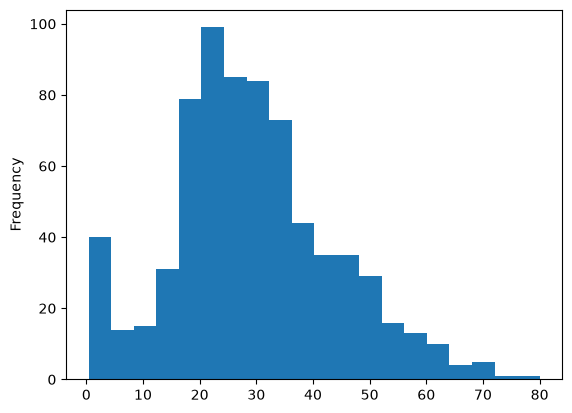

In [17]:
df.Age.plot(kind = "hist", bins = 20)

In [18]:
df_fillAge = df.copy()

df_fillAge.loc[:,"Age"] = df_fillAge.Age.fillna(value= age_median, inplace=False)

In [19]:
df_fillAge.isna().sum(axis = 0)

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
initials    0
dtype: int64

In [20]:
df_fillAge.Age.describe()

count    890.000000
mean      29.306933
std       12.979943
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

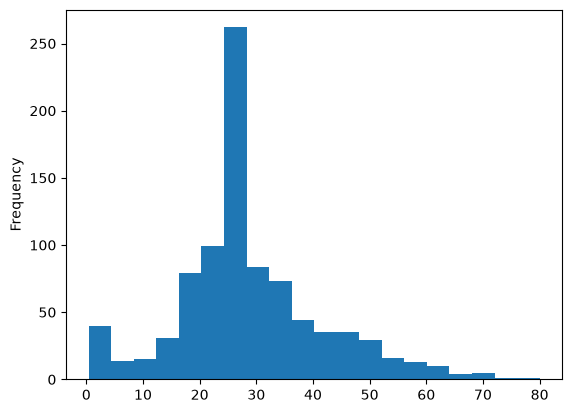

In [21]:
df_fillAge.Age.plot(kind = "hist", bins = 20)

In [22]:
# Inputation of Age wrt Gender
group_by_sex = df.groupby(by = "Sex")

In [23]:
median_ages = group_by_sex["Age"].transform("median")

In [24]:
df_fillAge_with_sex = df.copy()

df_fillAge_with_sex.loc[:,"Age"] = df_fillAge_with_sex.Age.fillna(
    value= median_ages
)

In [25]:
df_fillAge_with_sex.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
initials    0
dtype: int64

<Axes: ylabel='Frequency'>

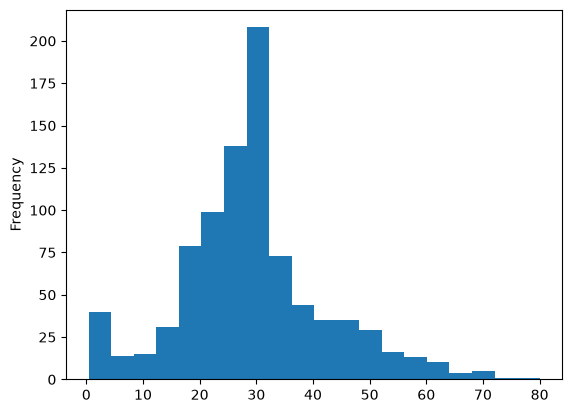

In [26]:
df_fillAge_with_sex.Age.plot(kind = "hist", bins = 20)

In [27]:
df.initials.value_counts()

initials
Mr              518
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

### Handling Null value for Age, using initials groups.

In [28]:
group_by_initials = df.groupby(by = "initials")

In [29]:
meadin_ages = group_by_initials["Age"].transform("median")

In [30]:
df_fillAge_with_initial = df.copy()

df_fillAge_with_initial.Age = df_fillAge_with_initial.Age.fillna(
    value= meadin_ages
)

<Axes: ylabel='Frequency'>

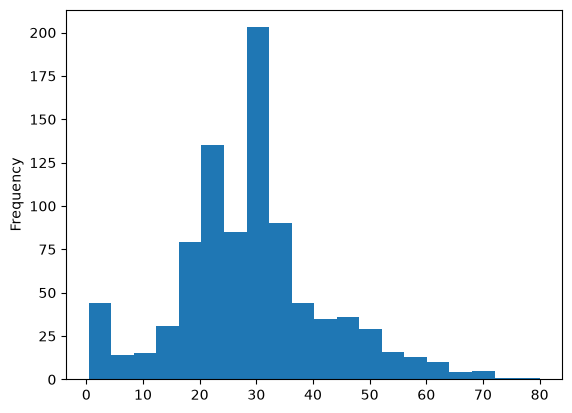

In [31]:
df_fillAge_with_initial.Age.plot(kind = "hist", bins = 20)

### Handling Null value for Age, using initials (Mr., Mrs,  Miss or Master)groups.

In [32]:
df.initials = df.initials.replace(
    to_replace=["Rev", "Major", "Col", "Don", "Sir", "Capt", "Jonkheer"], 
    value="Mr",
)

In [33]:
df.initials = df.initials.replace(
    to_replace= {"Mlle" : "Miss", "Mme" : "Mrs","Ms" : "Mrs","Lady" : "Mrs","the Countess" : "Mrs"}
)

In [34]:
def relace_with_gender(row):
    value = "Mr" if row.Sex == "male" else "Mrs"
    return row.initials.replace("Dr", value, True)

In [35]:
df.initials = df.apply(relace_with_gender, axis=1)

In [36]:
df.initials.value_counts()

initials
Mr        538
Miss      183
Mrs       129
Master     40
Name: count, dtype: int64

---

In [37]:
# Exercise

def get_initals(name):
    first_name = name.split(",")[-1]
    title = first_name.split(".")[0]
    return title.strip().lower()

initials = df.Name.apply(get_initals)
print(initials)

0        mr
1       mrs
2      miss
3       mrs
4        mr
       ... 
885    miss
886    miss
887      mr
888      mr
889      mr
Name: Name, Length: 890, dtype: str


In [38]:
# Aggregatee
df.Age.aggregate(["mean", "median"])

mean      29.631374
median    28.000000
Name: Age, dtype: float64

---

In [39]:
group_by_initials = df.groupby(by = "initials")

In [40]:
meadin_ages = group_by_initials["Age"].transform("median")

In [41]:
df_fillAge_with_initial = df.copy()

df_fillAge_with_initial.Age = df_fillAge_with_initial.Age.fillna(
    value= meadin_ages
)

<Axes: ylabel='Frequency'>

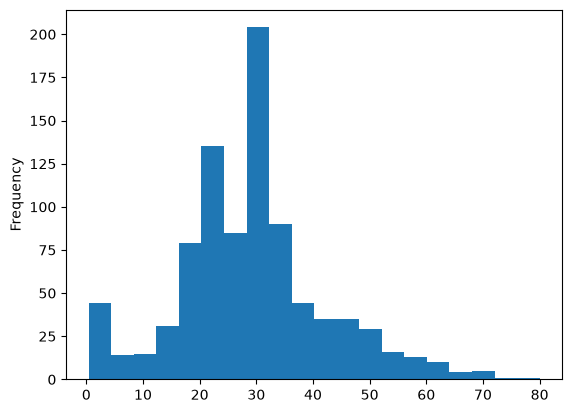

In [42]:
df_fillAge_with_initial.Age.plot(kind = "hist", bins = 20)

In [43]:
df_fillAge_with_initial.Age.describe()

count    890.000000
mean      29.317045
std       13.214172
min        0.420000
25%       21.000000
50%       30.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [44]:
df_fillAge_with_initial.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
initials    0
dtype: int64

### Cleaning Duplicates

In [45]:
df_fillAge_with_initial[df_fillAge_with_initial.duplicated()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
889,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.25,0,S,Mr


In [46]:
df_fillAge_with_initial.drop_duplicates(inplace=True)

In [47]:
# df_fillAge_with_initial.duplicated(subset=["Age", "Fare"])

## Data Management

**Type Conversion**

dataframe.astype()

In [48]:
df.dtypes

Survived    float64
Pclass      float64
Name            str
Sex             str
Age         float64
SibSp       float64
Parch       float64
Ticket          str
Fare        float64
Cabin         int64
Embarked        str
initials        str
dtype: object

In [49]:
df.Cabin = df.Cabin.astype(float)

In [50]:
df = df.astype({
    "Survived" : bool, "Pclass" : "int16"
})

In [51]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,False,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0.0,S,Mr
1,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1.0,C,Mrs
2,True,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0.0,S,Miss
3,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1.0,S,Mrs
4,False,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0.0,S,Mr


**Indexing**

get index -> dataframe.index

set index -> dataframe.index = Sequence or Series

reset index -> datafraem.reset_index

In [52]:
df.index

RangeIndex(start=0, stop=890, step=1)

In [53]:
df.set_index("Name", drop = True)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
Name,,,,,,,,,,,
"Braund, Mr. Owen Harris",False,3,male,22.0,1.0,0.0,A/5 21171,7.2500,0.0,S,Mr
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",True,1,female,38.0,1.0,0.0,PC 17599,71.2833,1.0,C,Mrs
"Heikkinen, Miss. Laina",True,3,female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0.0,S,Miss
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",True,1,female,35.0,1.0,0.0,113803,53.1000,1.0,S,Mrs
"Allen, Mr. William Henry",False,3,male,35.0,0.0,0.0,373450,8.0500,0.0,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
"Graham, Miss. Margaret Edith",True,1,female,19.0,0.0,0.0,112053,30.0000,1.0,S,Miss
"Johnston, Miss. Catherine Helen ""Carrie""",False,3,female,NaN,1.0,2.0,W./C. 6607,23.4500,0.0,S,Miss
"Behr, Mr. Karl Howell",True,1,male,26.0,0.0,0.0,111369,30.0000,1.0,C,Mr


In [54]:
df.reset_index(drop = True)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,False,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0.0,S,Mr
1,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1.0,C,Mrs
2,True,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0.0,S,Miss
3,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1.0,S,Mrs
4,False,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0.0,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
885,True,1,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,1.0,S,Miss
886,False,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,2.0,W./C. 6607,23.4500,0.0,S,Miss
887,True,1,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.0000,1.0,C,Mr
888,False,3,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.7500,0.0,Q,Mr
